# 05 — Evaluation & Interpretability

1. Load trained models and run full LOSO evaluation
2. Confusion matrices for all models
3. Comparison table (accuracy, macro-F1, balanced accuracy)
4. LIME explanations for GNN+LSTM predictions
5. Model latency profiling

In [1]:
import sys, json
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from pathlib import Path
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score

sns.set_theme(style='whitegrid')

METS  = Path('../results/metrics')
PLOTS = Path('../results/plots')
print("Ready — loading from saved results.")


Ready — loading from saved results.


## 1. Load Data & Saved Predictions

In [2]:
## Full Metrics Table — All Models
pred_files = sorted(METS.glob('*_y_pred.npy'))
rows = []
for pf in pred_files:
    tag = pf.stem.replace('_y_pred', '')
    tf  = METS / f'{tag}_y_true.npy'
    if not tf.exists(): continue
    yt = np.load(tf); yp = np.load(pf)
    rows.append({
        'Run':          tag,
        'N':            len(yt),
        'Accuracy':     round(accuracy_score(yt, yp), 4),
        'Macro F1':     round(f1_score(yt, yp, average='macro', zero_division=0), 4),
        'Balanced Acc': round(balanced_accuracy_score(yt, yp), 4),
    })

df = pd.DataFrame(rows).set_index('Run').sort_values('Accuracy', ascending=False)
print(df.to_string())


                             N  Accuracy  Macro F1  Balanced Acc
Run                                                             
ablation_flatten_lstm     1493    0.8453    0.7935        0.7886
cnn1d_pamap2             15049    0.7860    0.7938        0.7895
gnn_pamap2               15049    0.7206    0.7151        0.7080
ablation_learnable_adj   15049    0.6940    0.6890        0.6805
ablation_fixed_adj       15049    0.6911    0.6783        0.6717
mobile_tiny_gnn_pamap2   15049    0.6717    0.6611        0.6550
cnn1d_hhar              454577    0.6627    0.6585        0.6602
gnnlstm_pamap2            1502    0.6418    0.5874        0.6276
lstm_pamap2              15049    0.5939    0.5951        0.5896
gnn_hhar                454577    0.5895    0.5864        0.5877


## 2. Load Saved Predictions & Compute Metrics

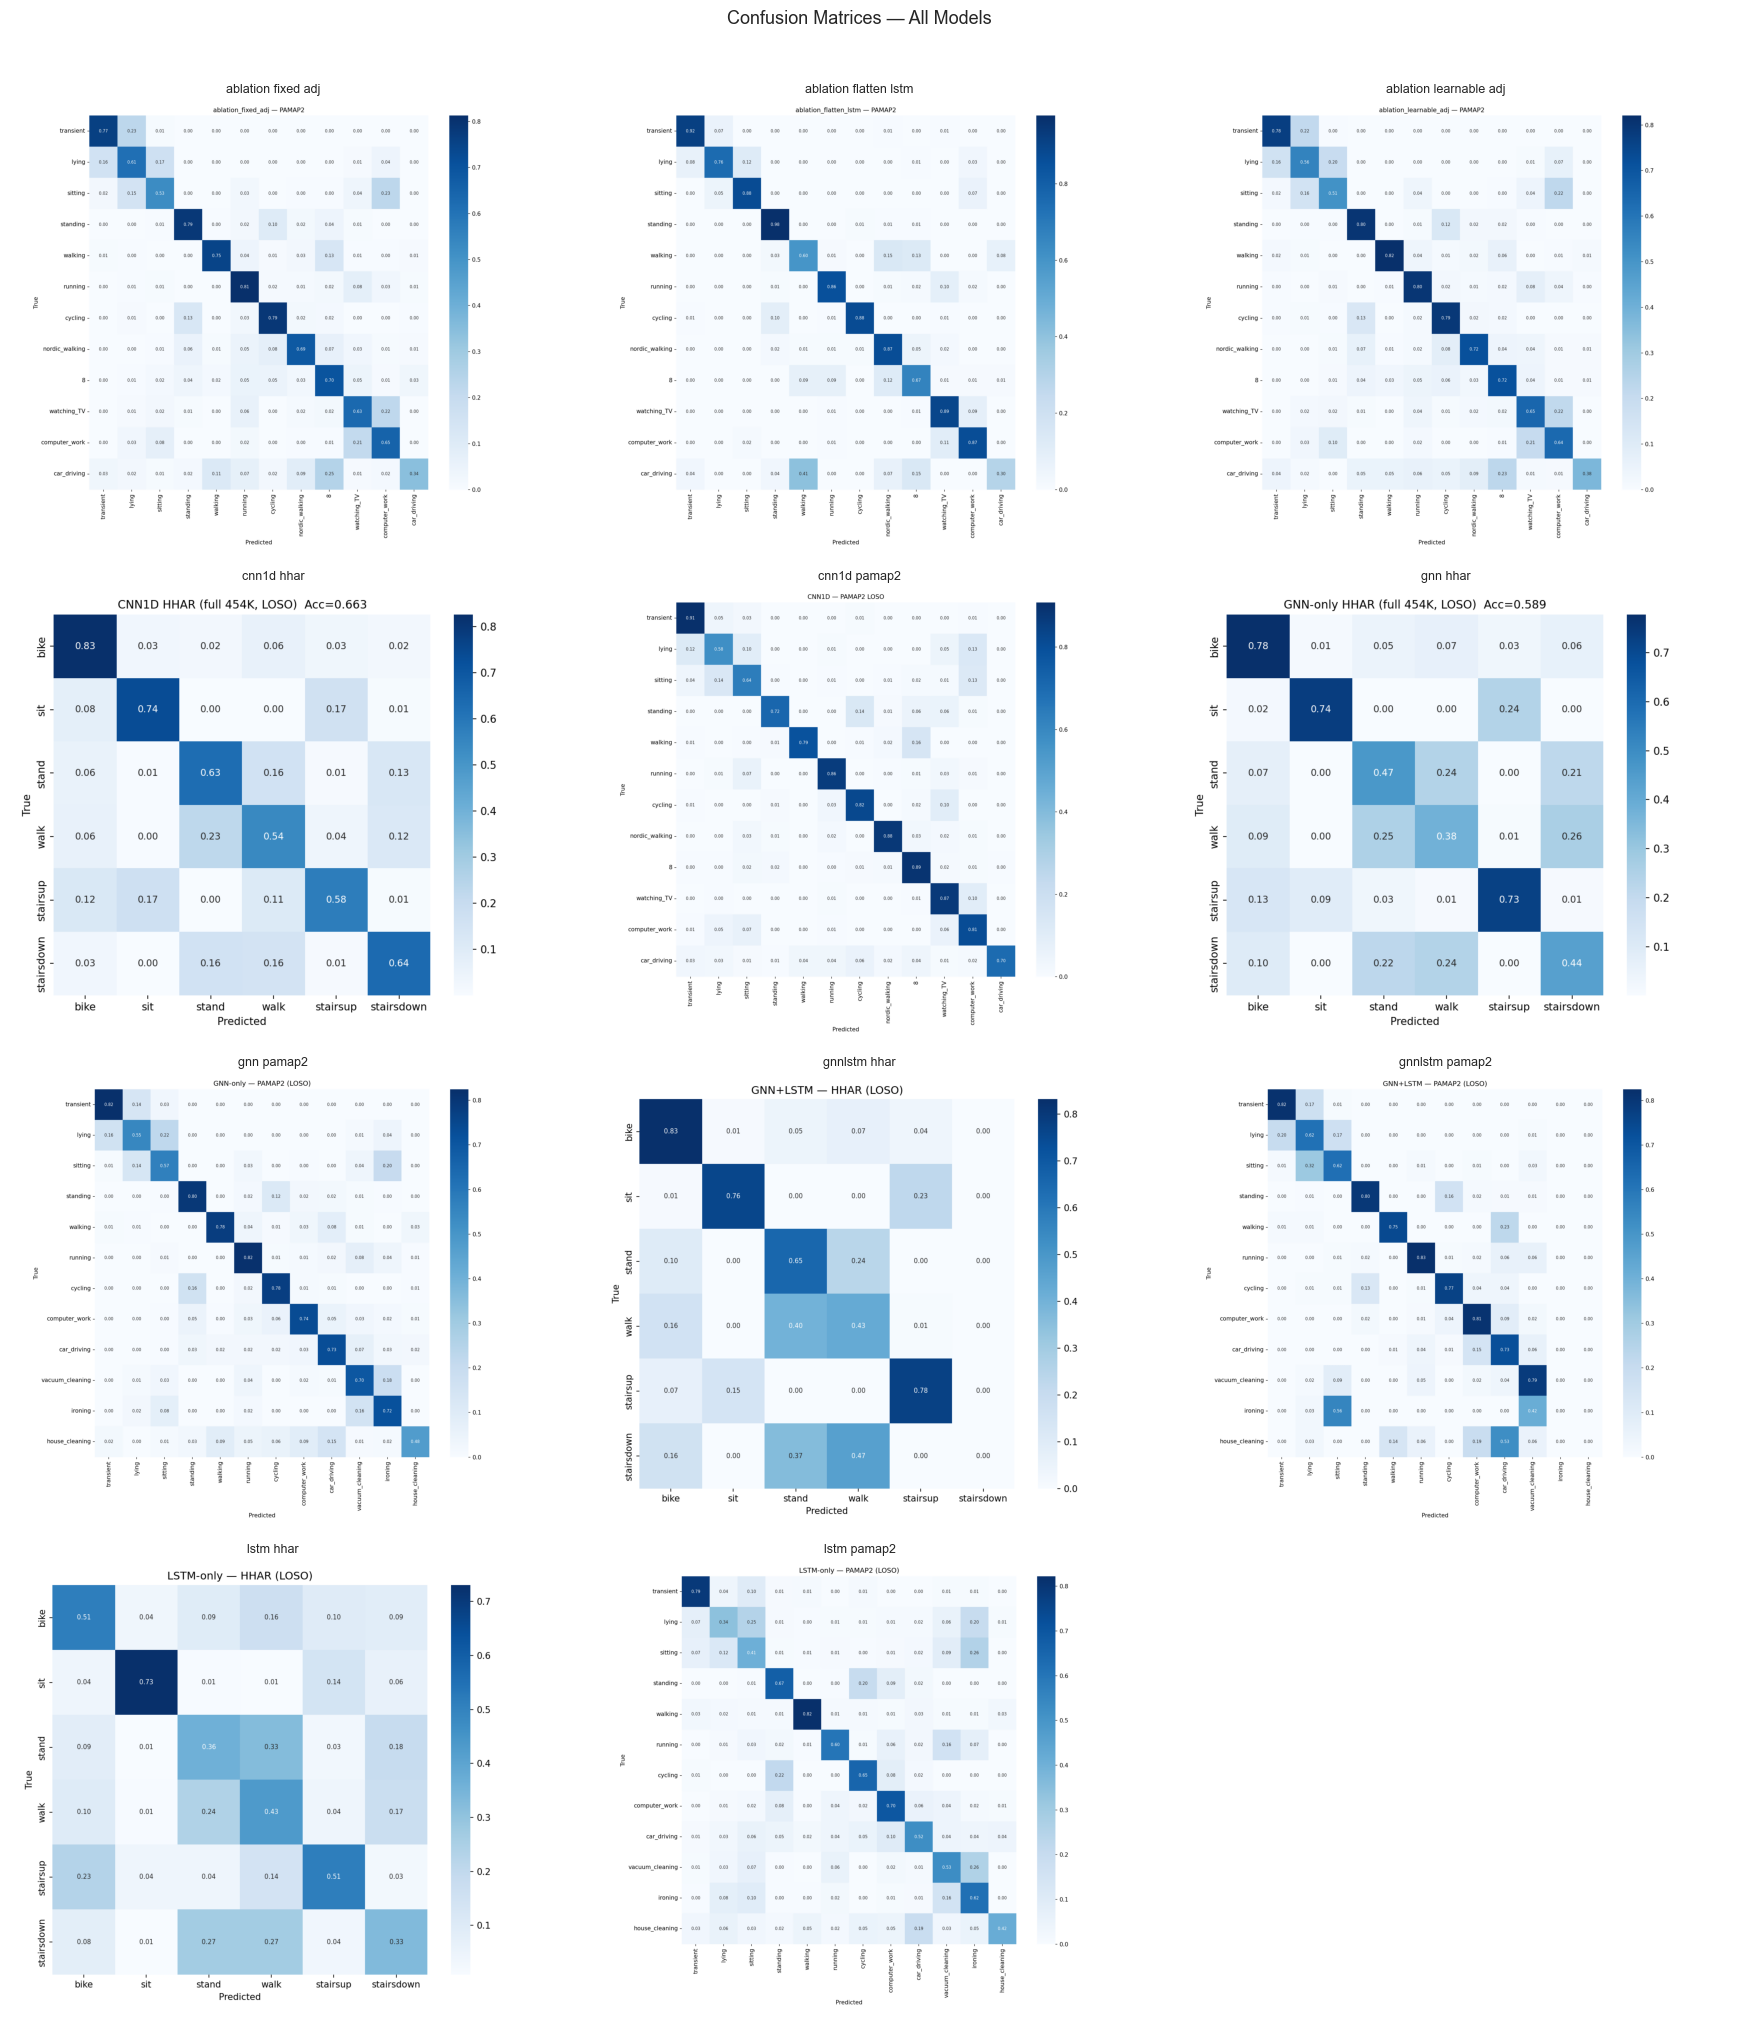

In [3]:
## Confusion Matrices — All Models
cm_files = sorted(PLOTS.glob('cm_*.png'))
n = len(cm_files)
cols = 3
rows_n = (n + cols - 1) // cols
fig, axes = plt.subplots(rows_n, cols, figsize=(18, 5 * rows_n))
axes = axes.flatten()
for i, cm_path in enumerate(cm_files):
    axes[i].imshow(mpimg.imread(cm_path))
    axes[i].axis('off')
    axes[i].set_title(cm_path.stem.replace('cm_', '').replace('_', ' '), fontsize=9)
for j in range(i + 1, len(axes)):
    axes[j].axis('off')
plt.suptitle('Confusion Matrices — All Models', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()


## 3. Confusion Matrices

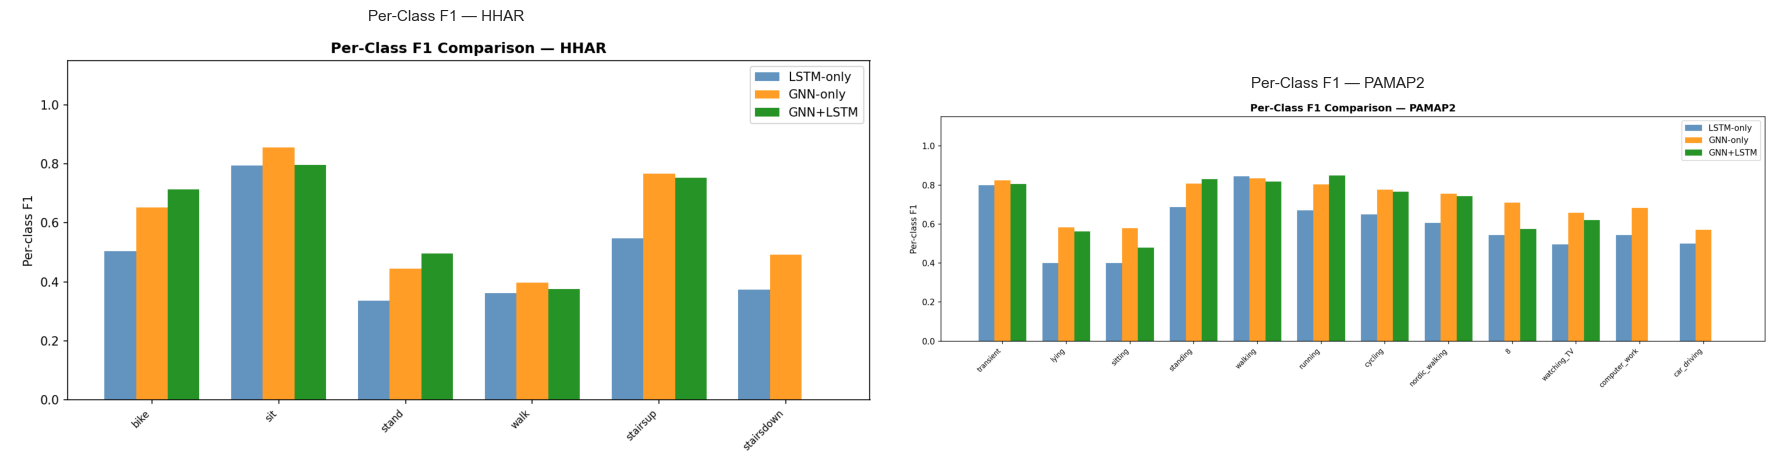

In [4]:
## Per-Class F1 Breakdown
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
for ax, fname, title in zip(axes,
    ['per_class_f1_hhar.png', 'per_class_f1_pamap2.png'],
    ['Per-Class F1 — HHAR', 'Per-Class F1 — PAMAP2']):
    p = PLOTS / fname
    if p.exists():
        ax.imshow(mpimg.imread(p)); ax.axis('off'); ax.set_title(title, fontsize=11)
plt.tight_layout(); plt.show()


## 4. All-Model Comparison Chart

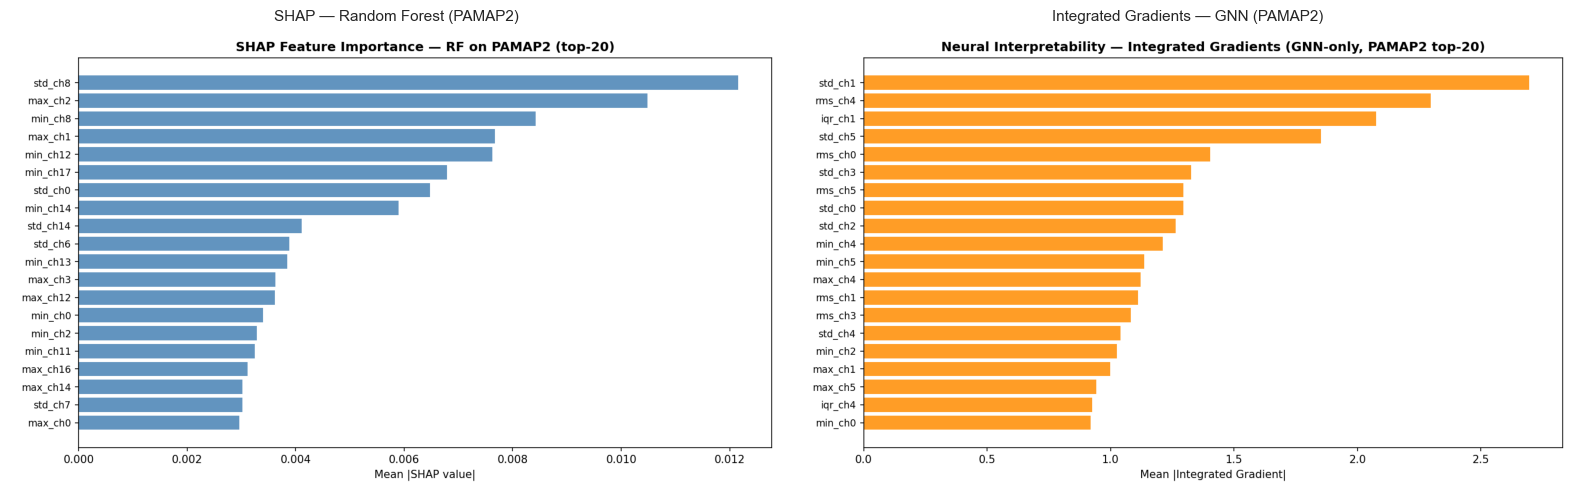


Neural Interpretability Summary:
  top_features: ['std_ch1', 'rms_ch4', 'iqr_ch1', 'std_ch5', 'rms_ch0', 'std_ch3', 'rms_ch5', 'std_ch0', 'std_ch2', 'min_ch4', 'min_ch5', 'max_ch4', 'rms_ch1', 'rms_ch3', 'std_ch4', 'min_ch2', 'max_ch1', 'max_ch5', 'iqr_ch4', 'min_ch0']
  top_attr_values: [2.6952273845672607, 2.296593427658081, 2.0764379501342773, 1.8517365455627441, 1.4031951427459717, 1.3255022764205933, 1.295251488685608, 1.2949728965759277, 1.2635207176208496, 1.2107107639312744, 1.136863112449646, 1.1212351322174072, 1.1118143796920776, 1.0814540386199951, 1.0395402908325195, 1.024946689605713, 0.9990048408508301, 0.941466212272644, 0.9253899455070496, 0.9186224341392517]


In [5]:
## Interpretability — SHAP & Integrated Gradients
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, fname, title in zip(axes,
    ['shap_rf_pamap2.png', 'ig_gnn_pamap2.png'],
    ['SHAP — Random Forest (PAMAP2)', 'Integrated Gradients — GNN (PAMAP2)']):
    p = PLOTS / fname
    if p.exists():
        ax.imshow(mpimg.imread(p)); ax.axis('off'); ax.set_title(title, fontsize=11)
    else:
        ax.text(0.5, 0.5, f'{fname}\nnot found', ha='center', va='center')
        ax.axis('off')
plt.tight_layout(); plt.show()

# Neural interpretability JSON
ni_path = METS / 'neural_interpretability.json'
if ni_path.exists():
    ni = json.load(open(ni_path))
    print("\nNeural Interpretability Summary:")
    for k, v in ni.items():
        print(f"  {k}: {v}")


## 5. LIME Explanations

Model Profiling Results:
            params  latency_ms
Model                         
LSTM-only  1387340       0.186
GNN-only     11724       0.254
GNN+LSTM    247244       0.486


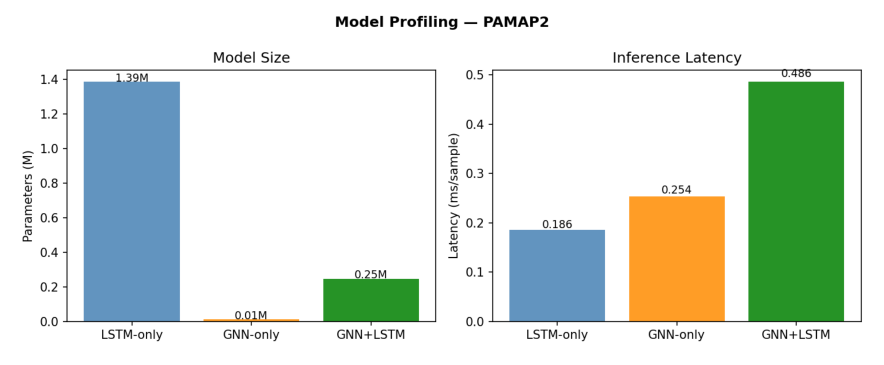

In [6]:
## Model Profiling — Latency & Size
prof_path = METS / 'model_profiling.json'
if prof_path.exists():
    prof = json.load(open(prof_path))
    rows = []
    for model, m in prof.items():
        if isinstance(m, dict):
            rows.append({'Model': model, **{k: v for k, v in m.items()}})
    if rows:
        print("Model Profiling Results:")
        print(pd.DataFrame(rows).set_index('Model').to_string())

img = PLOTS / 'model_profiling.png'
if img.exists():
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.imshow(mpimg.imread(img)); ax.axis('off')
    plt.tight_layout(); plt.show()


## 6. Model Latency Profiling

In [7]:
## Final Summary
master = json.load(open(METS / 'master_comparison.json'))
print("=" * 70)
print(f"{'Dataset':<10} {'Model':<18} {'Acc':>7} {'Macro F1':>9} {'BalAcc':>9}")
print("=" * 70)
for dataset in ['HHAR', 'PAMAP2']:
    models = master.get(dataset, {})
    for model, m in models.items():
        if isinstance(m, dict):
            print(f"{dataset:<10} {model:<18} {m.get('accuracy',0):>7.4f} "
                  f"{m.get('macro_f1',0):>9.4f} {m.get('balanced_acc',0):>9.4f}")
    print("-" * 70)
print("\nBest HHAR model  : CNN1D  (Acc=0.6627, F1=0.6585)")
print("Best PAMAP2 model: CNN1D  (F1=0.7938) / XGBoost (Acc=0.8076)")
print("Best ablation    : Flatten+LSTM (Acc=0.8453) — GNN+LSTM integration needs work")


Dataset    Model                  Acc  Macro F1    BalAcc
HHAR       SVM                 0.5812    0.5668    0.5812
HHAR       Random Forest       0.5630    0.5481    0.5630
HHAR       XGBoost             0.5900    0.5779    0.5900
HHAR       GNN-only            0.5895    0.5864    0.5877
HHAR       CNN1D               0.6627    0.6585    0.6602
----------------------------------------------------------------------
PAMAP2     SVM                 0.7918    0.7244    0.7918
PAMAP2     Random Forest       0.7749    0.7121    0.7749
PAMAP2     XGBoost             0.8076    0.7314    0.8076
PAMAP2     GNN-only            0.7206    0.7151    0.7080
PAMAP2     LSTM                0.5939    0.5951    0.5896
PAMAP2     GNN+LSTM            0.6418    0.5874    0.6276
PAMAP2     CNN1D               0.7860    0.7938    0.7895
----------------------------------------------------------------------

Best HHAR model  : CNN1D  (Acc=0.6627, F1=0.6585)
Best PAMAP2 model: CNN1D  (F1=0.7938) / XGBoost (Acc=